# Modelo A - Optimización

Este notebook optimiza los modelos candidatos del Modelo A limpio.

El Modelo A mantiene las reglas anti-leakage definidas en el proyecto:

- no usa `LV411`;
- no usa `SP_LT411`;
- no usa `LT411` como variable predictora;
- no usa lags ni deltas derivados de `LT411`.

El objetivo de este notebook es comparar los mejores modelos candidatos del baseline usando validación temporal.

El Día 3 se mantiene como test/anomalía y no se utiliza para elegir hiperparámetros.

In [1]:
# Importamos librerías para optimización con pipelines

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR



In [2]:
# Cargamos el dataset preparado para el Modelo A

df = pd.read_csv("data_limpio/features_modelo_A.csv")

df["Time"] = pd.to_datetime(df["Time"])

df.head()


,Time,bloque,LT411,DT412,INT_P101,FQC400_1_corr,FQC400_1_negativo_flag,FV400_1,PT442,PV442,...,TT415_delta_1,TT415_delta_6,PIT410_delta_1,PIT410_delta_6,PIT414_delta_1,PIT414_delta_6,DELTA_TT_delta_1,DELTA_TT_delta_6,DELTA_PIT_delta_1,DELTA_PIT_delta_6
0,2021-11-05 08:14:50,train,57.800925,1233.294202,58.336226,3040.664551,0,59.5,0.152228,0.0,...,0.000000,0.000000,-0.000223,-0.000350,-0.000810,-0.002257,0.000000,0.000000,-0.000587,-0.001907
1,2021-11-05 08:15:00,train,57.731480,1233.502551,58.472221,3031.220410,0,59.5,0.152402,0.0,...,-0.026042,-0.026042,-0.000318,0.000064,-0.001562,-0.002894,-0.008681,-0.008681,-0.001244,-0.002957
2,2021-11-05 08:15:10,train,58.622685,1233.294226,57.957175,3031.690015,0,59.5,0.152228,0.0,...,-0.060765,-0.086807,-0.000286,-0.000159,-0.000694,-0.004745,0.008681,0.000000,-0.000408,-0.004586
3,2021-11-05 08:15:20,train,59.343170,1233.385376,57.737267,3042.517261,0,59.5,0.152402,0.0,...,-0.026042,-0.112849,-0.000796,-0.001432,-0.000058,-0.004803,-0.013021,-0.013021,0.000738,-0.003371
4,2021-11-05 08:15:30,train,59.522568,1233.411389,57.974536,3053.772168,0,59.5,0.151881,0.0,...,-0.017361,-0.130211,-0.000223,-0.001751,-0.000521,-0.004167,0.013021,0.000000,-0.000298,-0.002416


In [3]:
# Separamos el dataset por bloques temporales

train = df[df["bloque"] == "train"].copy()

valid = df[df["bloque"] == "validacion"].copy()

test = df[df["bloque"] == "test"].copy()

In [4]:
# Definimos variables predictoras y target

columnas_no_modelo = ["Time", "bloque", "LT411"]

X_train = train.drop(columns=columnas_no_modelo)
y_train = train["LT411"]

X_valid = valid.drop(columns=columnas_no_modelo)
y_valid = valid["LT411"]

X_test = test.drop(columns=columnas_no_modelo)
y_test = test["LT411"]

In [5]:
# Revisamos tamaños de train, validación y test

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (8551, 222)
y_train: (8551,)
X_valid: (8551, 222)
y_valid: (8551,)
X_test: (5701, 222)
y_test: (5701,)


In [6]:
# Creamos una función simple para calcular métricas de regresión

def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    
    return mae, rmse, r2

In [7]:
# Definimos validación cruzada temporal para GridSearchCV

tscv = TimeSeriesSplit(n_splits=3)

## Modelos candidatos

A partir del baseline se mantienen como candidatos:

- `RandomForest`
- `GradientBoosting`
- `SVR`

Los modelos lineales quedan descartados porque tuvieron mal comportamiento en validación.

SVR se define con `Pipeline` porque necesita escalado de variables.

In [9]:
# Definimos los modelos candidatos

modelos = {
    "RandomForest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    ),
    
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR())
    ])
}

In [10]:
# Definimos los hiperparámetros de cada modelo

params = {
    "RandomForest": {
        "n_estimators": [200, 400],
        "max_depth": [8, 10, 15],
        "min_samples_leaf": [2, 5, 10],
        "max_features": ["sqrt", 0.7, 1.0]
    },
    
    "GradientBoosting": {
        "n_estimators": [100, 200, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.8, 1.0]
    },
    
    "SVR": {
        "svr__kernel": ["rbf"],
        "svr__C": [1, 10, 50],
        "svr__epsilon": [0.05, 0.1, 0.5],
        "svr__gamma": ["scale", "auto"]
    }
}

In [11]:
# Optimizamos cada modelo con GridSearchCV

resultados = []

mejores_modelos = {}

for nombre, modelo in modelos.items():
    
    print("Modelo:", nombre)
    
    gs = GridSearchCV(
        estimator=modelo,
        param_grid=params[nombre],
        cv=tscv,
        scoring="neg_mean_absolute_error",
        verbose=1,
        n_jobs=-1
    )
    
    gs.fit(X_train, y_train)
    
    mejor_modelo = gs.best_estimator_
    
    mejores_modelos[nombre] = mejor_modelo
    
    pred_train = mejor_modelo.predict(X_train)
    pred_valid = mejor_modelo.predict(X_valid)
    
    mae_train, rmse_train, r2_train = calcular_metricas(y_train, pred_train)
    mae_valid, rmse_valid, r2_valid = calcular_metricas(y_valid, pred_valid)
    
    resultados.append({
        "modelo": nombre,
        "MAE_CV": -gs.best_score_,
        "MAE_train": mae_train,
        "RMSE_train": rmse_train,
        "R2_train": r2_train,
        "MAE_valid": mae_valid,
        "RMSE_valid": rmse_valid,
        "R2_valid": r2_valid,
        "best_params": gs.best_params_
    })
    
    print("  Mejor MAE CV:", -gs.best_score_)
    print("  MAE validación:", mae_valid)
    print("  R2 validación:", r2_valid)
    print("  Mejores parámetros:", gs.best_params_)
    print("-" * 60)

Modelo: RandomForest
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  Mejor MAE CV: 2.2341077245430334
  MAE validación: 3.7595033543122836
  R2 validación: 0.20509452666631056
  Mejores parámetros: {'max_depth': 15, 'max_features': 0.7, 'min_samples_leaf': 10, 'n_estimators': 400}
------------------------------------------------------------
Modelo: GradientBoosting
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  Mejor MAE CV: 2.204779522034103
  MAE validación: 4.077275267559274
  R2 validación: 0.10522830953077023
  Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
------------------------------------------------------------
Modelo: SVR
Fitting 3 folds for each of 18 candidates, totalling 54 fits
  Mejor MAE CV: 2.2784442198801833
  MAE validación: 4.041634960671443
  R2 validación: 0.0672954154040617
  Mejores parámetros: {'svr__C': 1, 'svr__epsilon': 0.5, 'svr__gamma': 'auto', 'svr__kernel': 'rbf'}
----

## Comparativa de modelos optimizados

Se comparan los modelos por su error en validación externa.

El `gap_MAE` permite ver la diferencia entre error de validación y error de entrenamiento.

In [12]:
# Creamos tabla comparativa de modelos optimizados

df_resultados_opt = pd.DataFrame(resultados)

df_resultados_opt["gap_MAE"] = df_resultados_opt["MAE_valid"] - df_resultados_opt["MAE_train"]

df_resultados_opt = df_resultados_opt.sort_values("MAE_valid").reset_index(drop=True)

df_resultados_opt

,modelo,MAE_CV,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid,best_params,gap_MAE
0,RandomForest,2.234108,0.787947,1.048303,0.916087,3.759503,5.515856,0.205095,"{'max_depth': 15, 'max_features': 0.7, 'min_sa...",2.971557
1,SVR,2.278444,0.927134,1.241140,0.882376,4.041635,5.974853,0.067295,"{'svr__C': 1, 'svr__epsilon': 0.5, 'svr__gamma...",3.114501
2,GradientBoosting,2.204780,0.909157,1.137679,0.901169,4.077275,5.852094,0.105228,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",3.168118


In [13]:
# Seleccionamos el mejor modelo según MAE de validación

mejor_modelo_nombre = df_resultados_opt.loc[0, "modelo"]

mejor_modelo = mejores_modelos[mejor_modelo_nombre]

print("Mejor modelo optimizado:", mejor_modelo_nombre)

Mejor modelo optimizado: RandomForest


In [14]:
# Revisamos los mejores parámetros del modelo ganador

df_resultados_opt.loc[0, "best_params"]

{'max_depth': 15,
 'max_features': 0.7,
 'min_samples_leaf': 10,
 'n_estimators': 400}

## Evaluación visual en validación

Se grafica el mejor modelo optimizado en el bloque de validación.

Esta gráfica permite comprobar si el modelo solo mejora la métrica o si también sigue correctamente la dinámica temporal de LT411.

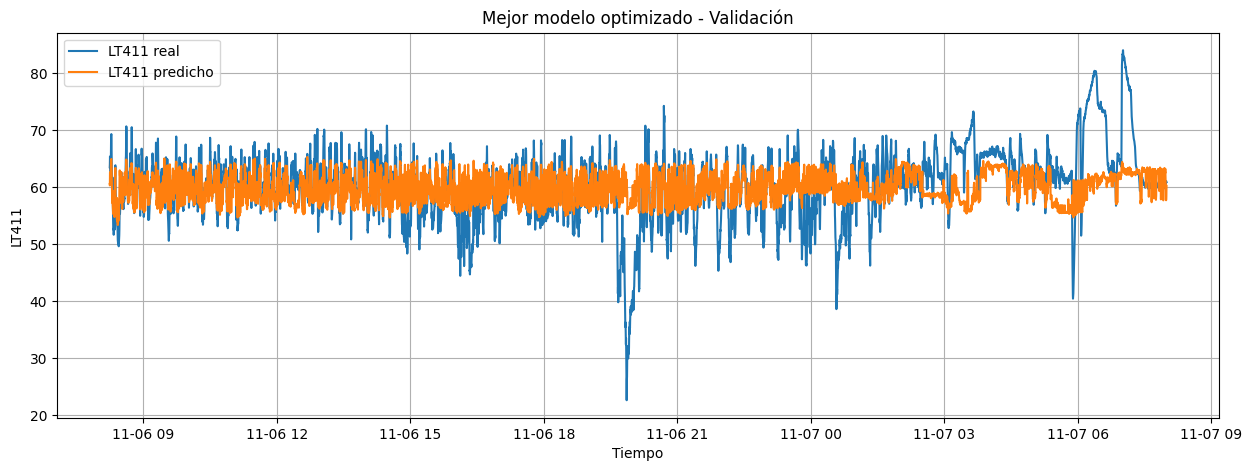

In [15]:
# Graficamos el mejor modelo en validación

pred_valid_mejor = mejor_modelo.predict(X_valid)

plt.figure(figsize=(15, 5))

plt.plot(valid["Time"], y_valid, label="LT411 real")
plt.plot(valid["Time"], pred_valid_mejor, label="LT411 predicho")

plt.title("Mejor modelo optimizado - Validación")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()

## Conclusiones de optimización

Con el dataset final de features del Modelo A, RandomForest obtiene el mejor resultado en validación externa.

El modelo mejora respecto al baseline inicial y consigue el menor MAE_valid, el menor RMSE_valid y el mejor R2_valid entre los tres candidatos optimizados.

SVR y GradientBoosting quedan como alternativas razonables, pero no superan a RandomForest en la validación externa.

El Día 3 no se utiliza para seleccionar el modelo. Se reserva para el siguiente notebook, donde se analizará el residual, la segmentación del test y la posible alerta de ensuciamiento/fallo del sensor.